In [ ]:
!pip install tensorflow streamlit joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import joblib

In [ ]:
dl = pd.read_csv("insurance.csv")

In [ ]:
dl.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
dl.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


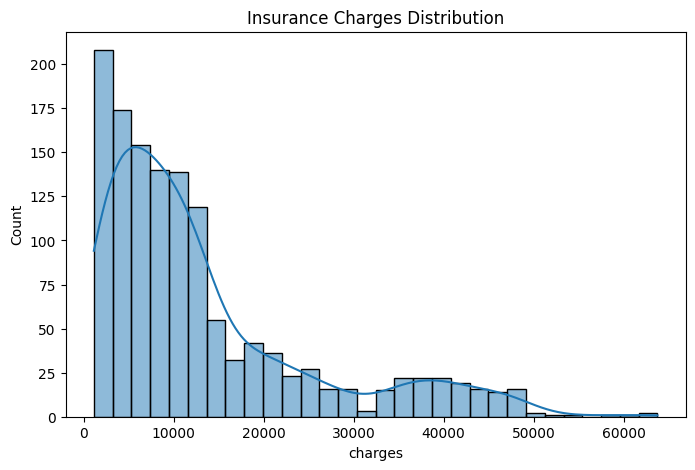

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(dl['charges'], kde=True)

plt.title("Insurance Charges Distribution")

plt.show()

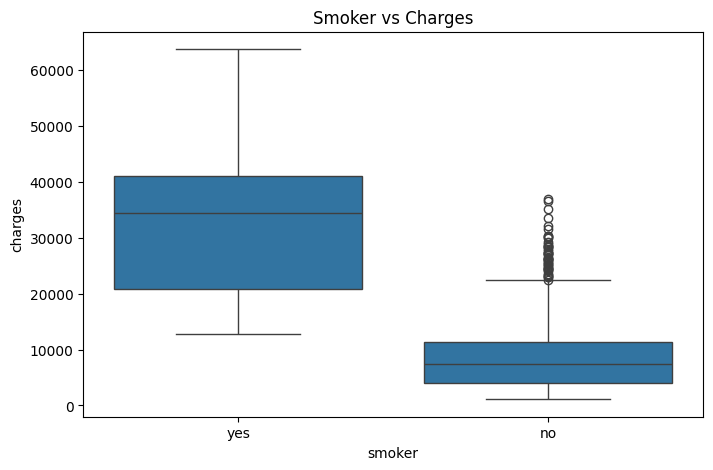

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=dl)

plt.title("Smoker vs Charges")

plt.show()

In [ ]:
le = LabelEncoder()

dl['sex'] = le.fit_transform(dl['sex'])

dl['smoker'] = le.fit_transform(dl['smoker'])

dl['region'] = le.fit_transform(dl['region'])

In [ ]:
dl.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
X = dl.drop('charges', axis=1)

y = dl['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

BUILD NEURAL NETWORK

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 325438944.0000 - mae: 13517.6475 - val_loss: 310285152.0000 - val_mae: 12652.6611
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 325238592.0000 - mae: 13511.0225 - val_loss: 309892192.0000 - val_mae: 12639.5957
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 324297312.0000 - mae: 13483.2148 - val_loss: 308362976.0000 - val_mae: 12591.2266
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 321411328.0000 - mae: 13395.2744 - val_loss: 303869472.0000 - val_mae: 12456.7041
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 313498304.0000 - mae: 13171.9658 - val_loss: 293237184.0000 - val_mae: 12146.9307
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 297473408.0000 - mae: 12702.7520 - val_loss: 272079840.0000 - val_mae: 11534.8564
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 267818400.0000 - mae: 11842.5400 - val_loss: 237494112.0000 - val_mae: 10495.2275
Epoch 8

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)

print("MAE:", mae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23912752.0000 - mae: 3111.5718 
Loss: 23912752.0
MAE: 3111.57177734375


In [ ]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MSE: 23912752.675866168
RMSE: 4890.066735318258
R2 Score: 0.8459713490339643


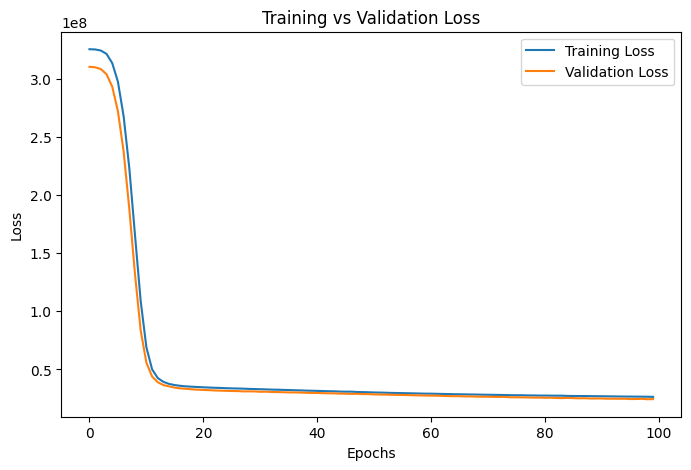

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [30]:
model.save("insurance_model.keras")

In [ ]:
from google.colab import files

files.download("insurance_model.h5")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
from google.colab import files

files.download("insurance_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
def predict_insurance(age, sex, bmi, children, smoker, region):

    sex = 0 if sex == "Male" else 1

    smoker = 1 if smoker == "Yes" else 0

    region_dict = {
        "Southwest": 0,
        "Southeast": 1,
        "Northwest": 2,
        "Northeast": 3
    }

    region = region_dict[region]

    input_data = np.array([[age, sex, bmi, children, smoker, region]])

    input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)

    return f"Predicted Insurance Cost: ${prediction[0][0]:,.2f}"

In [35]:
import gradio as gr
interface = gr.Interface(
    fn=predict_insurance,

    inputs=[
        gr.Number(label="Age"),
        gr.Radio(["Male", "Female"], label="Sex"),
        gr.Number(label="BMI"),
        gr.Number(label="Children"),
        gr.Radio(["Yes", "No"], label="Smoker"),
        gr.Dropdown(
            ["Southwest", "Southeast", "Northwest", "Northeast"],
            label="Region"
        )
    ],

    outputs="text",

    title="Medical Insurance Cost Prediction using Deep Learning",

    description="ANN-based Medical Insurance Cost Predictor"
)

In [36]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b3da074a0a1ce2ab29.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
